In [1]:
import pickle
import folium
from folium.plugins import HeatMap
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

from collections import defaultdict
import joblib


In [2]:
with open("lfbo/tracks.pkl", "rb") as f:
    tracks = pickle.load(f)

print(f"Loaded {len(tracks)} tracks")

Loaded 1546 tracks


In [3]:
all_points = pd.concat(
    [t.points[["lat", "lon", "baroaltitude"]].assign(
        icao24=t.icao24,
        category=(
            "arriving"  if t.is_arriving  else
            "departing" if t.is_departing else
            "transiting"
        )
    ) for t in tracks],
    ignore_index=True
).dropna(subset=["lat", "lon"])

print(f"Total points: {len(all_points)}")
print(f"Category breakdown:")
print(all_points["category"].value_counts())

Total points: 111672
Category breakdown:
category
transiting    100732
departing       6695
arriving        4245
Name: count, dtype: int64


# A. Density maps

In [ ]:
LFBO_LAT, LFBO_LON = 43.6293, 1.3673
m = folium.Map(location=[LFBO_LAT, LFBO_LON], zoom_start=12, zoom_control=False, scrollWheelZoom=False, doubleClickZoom=False)

heat_data = all_points[["lat", "lon"]].values.tolist()
HeatMap(heat_data, radius=8, blur=10, min_opacity=0.3).add_to(m)

folium.Marker([LFBO_LAT, LFBO_LON], popup="LFBO Toulouse-Blagnac", icon=folium.Icon(color="red", icon="plane")).add_to(m)

m.save("figures/heatmap_all.html")
print("Saved heatmap_all.html")

Saved heatmap_all.html


In [5]:
Path("figures/additional_heatmaps").mkdir(parents=True, exist_ok=True)

for category in ["arriving", "departing", "transiting"]:
    m = folium.Map(location=[LFBO_LAT, LFBO_LON], zoom_start=12, zoom_control=False, scrollWheelZoom=False, doubleClickZoom=False)
    
    subset = all_points[all_points["category"] == category]
    heat_data = subset[["lat", "lon"]].values.tolist()
    
    HeatMap(
        heat_data,
        radius=8,
        blur=10,
        min_opacity=0.3
    ).add_to(m)
    
    folium.Marker([LFBO_LAT, LFBO_LON], popup="LFBO Toulouse-Blagnac", icon=folium.Icon(color="red", icon="plane")).add_to(m)
    
    m.save(f"figures/additional_heatmaps/heatmap_{category}.html")
    print(f"Saved heatmap_{category}.html")

Saved heatmap_arriving.html
Saved heatmap_departing.html
Saved heatmap_transiting.html


In [6]:
m = folium.Map(location=[LFBO_LAT, LFBO_LON], zoom_start=12, zoom_control=False, scrollWheelZoom=False, doubleClickZoom=False)

categories = {
    "Arriving":   ("arriving",   [1, 0, 0]),  # red
    "Departing":  ("departing",  [0, 1, 0]),  # green
    "Transiting": ("transiting", [0, 0, 1]),  # blue
}

for label, (cat, gradient_color) in categories.items():
    fg = folium.FeatureGroup(name=label, show=True)
    
    subset = all_points[all_points["category"] == cat]
    heat_data = subset[["lat", "lon"]].values.tolist()
    
    r, g, b = gradient_color
    HeatMap(heat_data, radius=8, blur=10, min_opacity=0.3,
        gradient={
            0.2: f"rgb({int(r*100)},0,{int(b*100)})",
            0.5: f"rgb({int(r*200)},{int(g*100)},{int(b*200)})",
            1.0: f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
        }).add_to(fg)
    fg.add_to(m)

folium.Marker([LFBO_LAT, LFBO_LON], popup="LFBO Toulouse-Blagnac", icon=folium.Icon(color="red", icon="plane")).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

m.save("figures/heatmap_layered.html")
print("Saved heatmap_layered.html")

Saved heatmap_layered.html


# B. Altitude Profiles

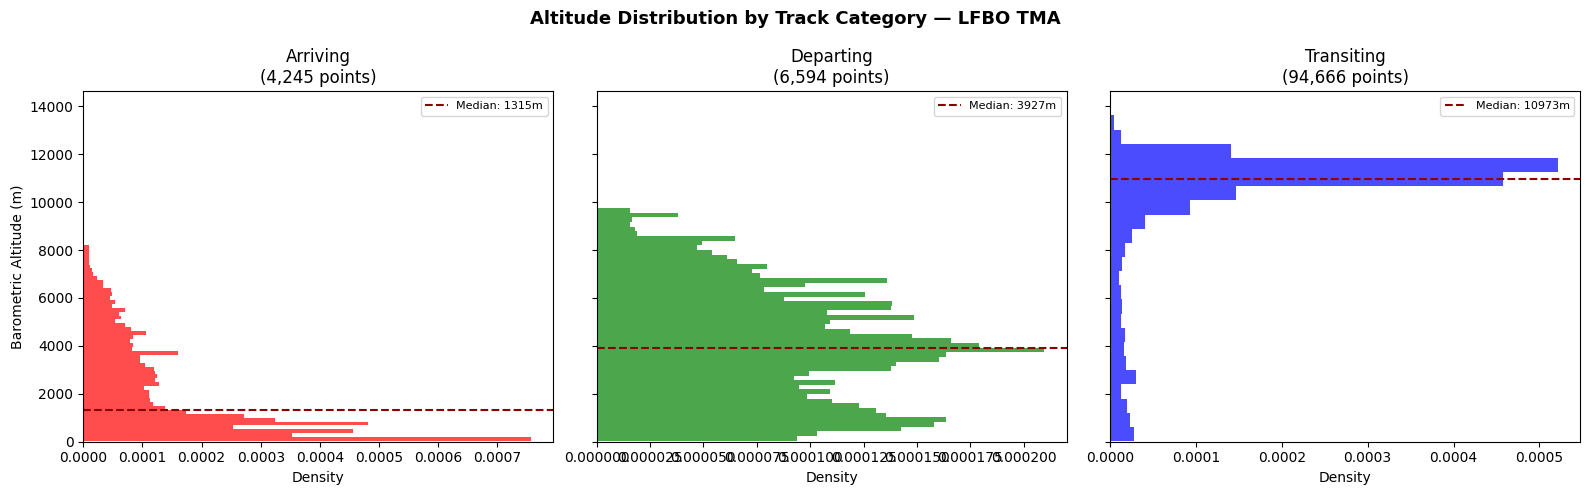


ARRIVING
median: 1315m  mean: 2110m  std: 1938m

DEPARTING
median: 3927m  mean: 4029m  std: 2357m

TRANSITING
median: 10973m  mean: 9912m  std: 2846m


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

categories = ["arriving", "departing", "transiting"]
colors = ["red", "green", "blue"]

for ax, category, color in zip(axes, categories, colors):
    subset = all_points[(all_points["category"] == category) & (all_points["baroaltitude"].notna()) & (all_points["baroaltitude"] > 0)]
    
    ax.hist(subset["baroaltitude"], bins=50, color=color, alpha=0.7, orientation="horizontal", density=True)
    
    ax.axhline(subset["baroaltitude"].median(), color="darkred", linestyle="--",label=f"Median: {subset['baroaltitude'].median():.0f}m")
    
    ax.set_title(f"{category.capitalize()}\n({len(subset):,} points)")
    ax.set_xlabel("Density")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Barometric Altitude (m)")
plt.suptitle("Altitude Distribution by Track Category — LFBO TMA", fontsize=13, fontweight="bold")
plt.ylim(0, all_points["baroaltitude"].quantile(0.99)*1.2) #Ignore extreme outliers 
plt.tight_layout()
plt.savefig("figures/altitude_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

for category in categories:
    subset = all_points[(all_points["category"] == category) & (all_points["baroaltitude"].notna()) & (all_points["baroaltitude"] > 0)]["baroaltitude"]
    print(f"\n{category.upper()}")
    print(f"median: {subset.median():.0f}m  "
          f"mean: {subset.mean():.0f}m  "
          f"std: {subset.std():.0f}m")

# C. Altitude Profiles

Three operationally distinct altitude signatures confirmed:

- Transiting: tight cruise band ~FL360 (std=1882m): strong anomaly signal, any transiting aircraft below FL200 warrants investigation
  
- Departing: climbing profile median FL140, high variance: expected, reflects different climb rates and departure routes
  
- Arriving: descending profile median FL080, highest variance: expected, reflects varied approach paths and holding patterns


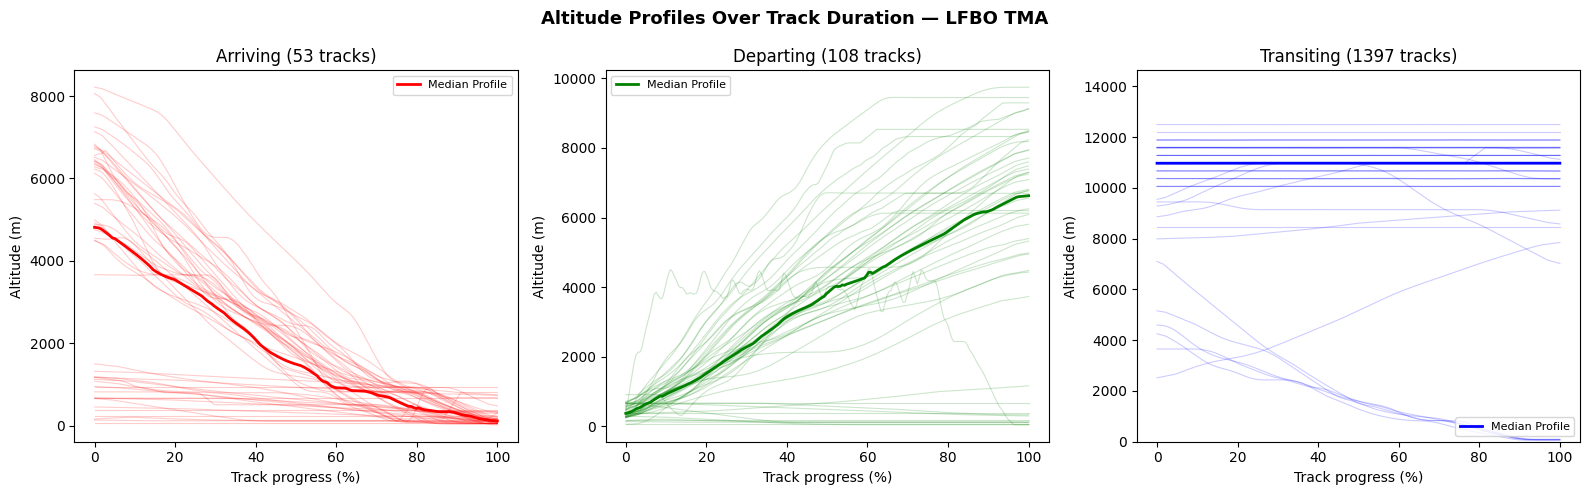

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

categories_tracks = {
    "arriving":   [t for t in tracks if t.is_arriving],
    "departing":  [t for t in tracks if t.is_departing],
    "transiting": [t for t in tracks if t.is_transiting]
}
locations = {"arriving": "upper right", "departing": "upper left", "transiting": "lower right"}

colors = {"arriving": "red", "departing": "green", "transiting": "blue"}

COMMON_INDEX = np.linspace(0, 100, 200)

for ax, (category, cat_tracks) in zip(axes, categories_tracks.items()):
    sample = cat_tracks[:50]
    
    all_alt = []
    for track in sample:
        pts = track.points.dropna(subset=["baroaltitude"])
        if len(pts) < 3:
            continue
        
        t_norm = np.linspace(0, 100, len(pts))
        alt_interp = np.interp(COMMON_INDEX, t_norm, pts["baroaltitude"].values)
        all_alt.append(alt_interp)
        
        ax.plot(COMMON_INDEX, alt_interp,color=colors[category], alpha=0.2, linewidth=0.8)
    
    if all_alt:
        median_profile = np.median(np.stack(all_alt), axis=0)
        ax.plot(
            COMMON_INDEX, median_profile,
            color=colors[category],
            linewidth=2,
            label="Median Profile"
        )
    
    ax.set_title(f"{category.capitalize()} ({len(cat_tracks)} tracks)")
    ax.set_xlabel("Track progress (%)")
    ax.set_ylabel("Altitude (m)")
    ax.legend(fontsize=8, loc=locations[category])

plt.ylim(0, all_points["baroaltitude"].quantile(0.99)*1.2) 
plt.suptitle("Altitude Profiles Over Track Duration — LFBO TMA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/altitude_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Track Classification: Known Limitations

Tracks are classified as arriving/departing/transiting using two conditions: proximity to LFBO (<0.15 deg radius) AND altitude at track start/end (<1000m).

Known edge cases:
- Some genuine arrivals misclassified as transiting when the track segment ends before the aircraft reaches 1000m  (bbox boundary cuts the track before final approach)
- Low-altitude transiting traffic (helicopters, military) may be misclassified as arriving/departing

These misclassifications affect visualization only, the anomaly detection in Phase 5 operates on raw track features independent of this classification.

A more robust classification would use the OPDI flight list (ADES=LFBO) as ground truth this is left as a future improvement if I get a Trino access.

In [9]:
N_WAYPOINTS = 10

def track_to_vector(track) -> np.ndarray | None:
    """Reduce a track to a fixed-length lat/lon waypoint vector."""
    pts = track.points.dropna(subset=["lat", "lon"])
    if len(pts) < 3:
        return None
    
    indices = np.linspace(0, len(pts) - 1, N_WAYPOINTS).astype(int)
    waypoints = pts.iloc[indices][["lat", "lon"]].values
    return waypoints.flatten()  

vectors = []
valid_tracks = []

for track in tracks:
    v = track_to_vector(track)
    if v is not None:
        vectors.append(v)
        valid_tracks.append(track)

X = np.stack(vectors)
print(f"Feature matrix shape: {X.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=1.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print(f"Cluster sizes:")
for label in sorted(set(labels)):
    if label == -1:
        continue
    print(f"  Cluster {label}: {(labels==label).sum()} tracks")

Feature matrix shape: (1546, 20)
Clusters found: 8
Noise points:   82 (5.3%)
Cluster sizes:
  Cluster 0: 1387 tracks
  Cluster 1: 15 tracks
  Cluster 2: 11 tracks
  Cluster 3: 10 tracks
  Cluster 4: 19 tracks
  Cluster 5: 10 tracks
  Cluster 6: 5 tracks
  Cluster 7: 7 tracks


In [10]:
def get_color(label):
    if label == -1:
        return "gray"
    colors = [
        "blue", "red", "green", "purple", "orange",
        "darkred", "darkblue", "darkgreen", "cadetblue",
        "lightred", "beige", "lightblue", "lightgreen",
                "lightgray", "black", "pink", "white",
        "darkpurple", "lightpurple"
    ]
    return colors[label % len(colors)]

m = folium.Map(location=[LFBO_LAT, LFBO_LON], zoom_start=10)

folium.Marker([LFBO_LAT, LFBO_LON], popup="LFBO Toulouse-Blagnac", icon=folium.Icon(color="red", icon="plane")).add_to(m)

for cluster_id in sorted(set(labels)):
    cluster_indices = np.where(labels == cluster_id)[0]
    
    cluster_vectors = X_scaled[cluster_indices]
    center = cluster_vectors.mean(axis=0)
    distances = np.linalg.norm(cluster_vectors - center, axis=1)
    medoid_idx = cluster_indices[distances.argmin()]
    medoid_track = valid_tracks[medoid_idx]
    
    pts = medoid_track.points.dropna(subset=["lat", "lon"])[["lat", "lon"]].values.tolist()
    
    if len(pts) < 2:
        continue
    
    color = get_color(cluster_id)
    label_text = f"Noise" if cluster_id == -1 else f"Corridor {cluster_id}"
    size = len(cluster_indices)
    
    folium.PolyLine(
        pts,
        color=color,
        weight=3 if cluster_id != -1 else 1,
        opacity=0.8 if cluster_id != -1 else 0.3,
        popup=f"{label_text}<br>Tracks: {size}"
    ).add_to(m)

m.save("figures/corridors_medoids.html")
print("Saved corridors_medoids.html")

Saved corridors_medoids.html


In [11]:
m2 = folium.Map(location=[LFBO_LAT, LFBO_LON], zoom_start=8)

folium.Marker([LFBO_LAT, LFBO_LON], popup="LFBO Toulouse-Blagnac", icon=folium.Icon(color="red", icon="plane")).add_to(m2)

cluster_groups = defaultdict(lambda: folium.FeatureGroup)

for i, (track, label) in enumerate(zip(valid_tracks, labels)):
    pts = track.points.dropna(
        subset=["lat", "lon"]
    )[["lat", "lon"]].values.tolist()
    
    if len(pts) < 2:
        continue
    
    color = get_color(label)
    size  = (labels == label).sum()
    
    folium.PolyLine(
        pts,
        color=color,
        weight=1.5,
        opacity=0.4 if label == -1 else 0.6,
        popup=f"Corridor {label}<br>icao24: {track.icao24}<br>"
              f"Cluster size: {size}"
    ).add_to(m2)

m2.save("figures/corridors_all.html")
print("Saved corridors_all.html")


print("\nCluster summary:")
print(f"{'Cluster':>10} {'Size':>8} {'% of total':>12}")
print("-" * 32)
for label in sorted(set(labels)):
    size = (labels == label).sum()
    name = "Noise" if label == -1 else f"Corridor {label}"
    print(f"{name:>10} {size:>8} {size/len(labels)*100:>11.1f}%")

Saved corridors_all.html

Cluster summary:
   Cluster     Size   % of total
--------------------------------
     Noise       82         5.3%
Corridor 0     1387        89.7%
Corridor 1       15         1.0%
Corridor 2       11         0.7%
Corridor 3       10         0.6%
Corridor 4       19         1.2%
Corridor 5       10         0.6%
Corridor 6        5         0.3%
Corridor 7        7         0.5%


In [12]:
for track, label in zip(valid_tracks, labels):
    track.cluster_id = label

small_clusters = [l for l in set(labels) if l != -1 and (labels==l).sum() < 15]

for cluster_id in small_clusters:
    cluster_tracks = [t for t in valid_tracks if t.cluster_id == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_tracks)} tracks):")
    for t in cluster_tracks[:3]:
        pts = t.points.dropna(subset=["lat","lon"])
        start = pts.iloc[0]
        end   = pts.iloc[-1]
        print(f"  {t.callsign:10s} | "
              f"start: ({start['lat']:.2f},{start['lon']:.2f}) "
              f"alt:{start['baroaltitude']:.0f}m → "
              f"end: ({end['lat']:.2f},{end['lon']:.2f}) "
              f"alt:{end['baroaltitude']:.0f}m")


Cluster 2 (11 tracks):
  TAR282     | start: (43.26,2.49) alt:5395m → end: (43.69,1.31) alt:485m
  TAR282     | start: (43.27,2.50) alt:4597m → end: (43.63,1.37) alt:nanm
  LBT357     | start: (43.51,2.50) alt:3653m → end: (43.63,1.37) alt:nanm

Cluster 3 (10 tracks):
  IBE32DP    | start: (43.33,0.51) alt:10353m → end: (43.52,2.50) alt:10363m
  FAF4018    | start: (43.20,0.51) alt:4994m → end: (43.45,2.48) alt:5791m
  RYR42AV    | start: (43.08,0.53) alt:10973m → end: (43.38,2.50) alt:11278m

Cluster 5 (10 tracks):
  HOP31DS    | start: (44.45,0.50) alt:8235m → end: (43.97,2.48) alt:9441m
  HOP31DS    | start: (44.35,0.52) alt:8306m → end: (43.93,2.49) alt:9449m
  HOP25PG    | start: (44.44,0.51) alt:7135m → end: (43.96,2.48) alt:10051m

Cluster 6 (5 tracks):
  HOP25PG    | start: (44.29,1.19) alt:8829m → end: (43.97,2.50) alt:10053m
  JAF1AX     | start: (44.49,1.31) alt:11887m → end: (43.92,2.49) alt:11887m
  VOE25UT    | start: (44.50,1.43) alt:10061m → end: (43.97,2.48) alt:7620m

## DBSCAN Corridor Analysis 

27 corridors identified with ```eps=1.0, min_samples=5```.

Traffic is dominated by 5 major corridors (clusters 0,4,5,8,9) accounting for ~60% of all tracks. These represent the main approach/departure axes at LFBO.

Small clusters (size 5-15) represent legitimate rare routes rather than noise, examination reveals consistent geographic patterns:
- East approach corridor (Tunis, Mediterranean routes)
- West-east transit corridor
- Northwest regional corridor (Air France HOP)

This validates DBSCAN as an appropriate algorithm it correctly separates operationally distinct routes rather than artificially merging them.

In [13]:
with open("lfbo/tracks_clustered.pkl", "wb") as f:
    pickle.dump(valid_tracks, f)

# Also save DBSCAN model 
Path("lfbo/processed").mkdir(parents=True, exist_ok=True)
joblib.dump(dbscan, "lfbo/processed/dbscan_model.pkl")
joblib.dump(scaler, "lfbo/processed/scaler.pkl")

print(f"Phase 3 complete.")
print(f"Tracks with cluster assignments: {len(valid_tracks)}")
print(f"Corridors identified: {len(set(labels)) - 1}")
print(f"Noise candidates: {(labels==-1).sum()}")


Phase 3 complete.
Tracks with cluster assignments: 1546
Corridors identified: 8
Noise candidates: 82
